## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maleah Caboteja

**Date:** Sept 30th


Q1: 
1. Regression predicts a numeric outcome, such as baseline sales. Classification predicts a category such as class.
2. A confusion matrix counts prediction by actual class and predicted class. It helps to cross reference the actual class versus predicted class. 
3. SSE quanitifies the total unexplained variation or discrepancy between the observed actual values and the values predicted by the model.
4. Overfitting is when K is too small and creates overcomplexity, whereas underfitting is when K is too large and is oversimplifies.
5. By splitting the data and choosing an appropriate k value on our set, we can reduce ovefitting and evaluate how well the model generalizes to unseen data.
6. A class label is simple and easy to interpret. However, it hides the model's uncertainty. Probability distribution gives us more information about confidence and uncertainty. But it also is more complex and the probabilities might not be as accurate.


    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
(338, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   so

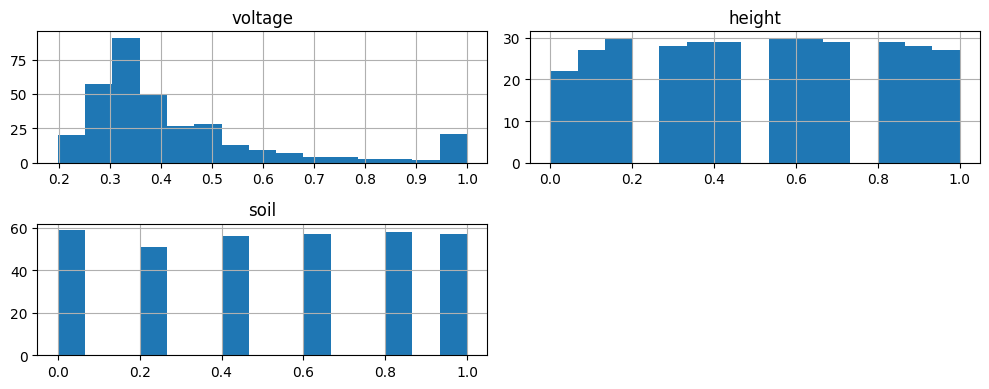

Size of training: 169
Size of test:  169
Training proportions: 
mine_type
1            0.207101
2            0.207101
3            0.195266
4            0.195266
5            0.195266
Name: proportion, dtype: float64
Test proportions:
mine_type
1            0.213018
2            0.207101
3            0.195266
4            0.195266
5            0.189349
Name: proportion, dtype: float64
Scaled feature range: 
     voltage  height  soil
min      0.0     0.0   0.0
max      1.0     1.0   1.0
k =  1 Accuracy =  0.462
k =  3 Accuracy =  0.385
k =  5 Accuracy =  0.355
k =  7 Accuracy =  0.337
k =  9 Accuracy =  0.373
k =  11 Accuracy =  0.379
k =  15 Accuracy =  0.385
Best k:  1
Accuracy of Test:  0.462
Accuracy % 46.15


/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A col

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,21,0,4,4,7
Actual 2,0,32,0,3,0
Actual 3,8,0,7,10,8
Actual 4,7,5,4,11,6
Actual 5,7,0,9,9,7


In [34]:
# Your Phase 1 solution to the problem goes here.

from matplotlib import pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
#Q2
#I answered the questions in the comments under the question number :)


#1. 

#loads csv data and performs multiple EDA
df = pd.read_csv('data/land_mines.csv')
print(df.head())
print(df.describe())
print(df.shape)

print(df.info())
print(df.isnull().sum())

#summarizes the target label and features
print(df["mine_type"].value_counts().sort_index())
print(df["mine_type"].value_counts(normalize=True).sort_index())

feature_stats = ["voltage","height","soil"]
print(df[feature_stats].describe())

#looks at a histogram layout of the features
df[feature_stats].hist(figsize=(10,4), bins=15)
plt.tight_layout()
plt.show()

#2.
#looks at all mine types to evaluate
feature_x = df[["voltage", "height", "soil"]]
feature_y = df[["mine_type"]]
train_x, test_x, train_y, test_y = train_test_split(feature_x,feature_y,test_size=0.50,random_state=42,stratify=feature_y)


print("Size of training:", len(train_x))
print("Size of test: ", len(test_x))
print("Training proportions: ")
print(train_y.value_counts(normalize=True).sort_index())
print("Test proportions:")
print(test_y.value_counts(normalize=True).sort_index())

#3. 
#I tested multiple values of k (1,3,5,7,9,11,15) and compared the accuracy of them, and then selected the k with 
# the highest accuracy. I selected k = 1 because it had the highest accuracy of about 46.2% in comparison 
# to the other values. The final model I made had a test accuracy of 46.15%. 

#scales the mining features based off what we did in class
scaler = MinMaxScaler()
train_x_scaled = pd.DataFrame(scaler.fit_transform(train_x),columns=train_x.columns,index=train_x.index)
test_x_scaled = pd.DataFrame(scaler.transform(test_x),columns=test_x.columns,index=test_x.index)

print("Scaled feature range: ")
print(train_x_scaled.agg(["min", "max"]).round(3))

#builds k-NN classifiers, choosing k values
values = [1,3,5,7,9,11,15]

for k in values:
    model_k = KNeighborsClassifier(n_neighbors=k)
    fitted_k_model = model_k.fit(train_x_scaled, train_y)
    hat_y = fitted_k_model.predict(test_x_scaled)
    accuracy = accuracy_score(test_y,hat_y)

    print("k = ",k,"Accuracy = ", round(accuracy,3))

#final model and the accuracy

highest_k = 1
model_k = KNeighborsClassifier(n_neighbors=highest_k)
fitted_k_model = model_k.fit(train_x_scaled, train_y)
hat_y = fitted_k_model.predict(test_x_scaled)

accuracy = accuracy_score(test_y,hat_y)

print("Best k: ", highest_k)
print("Accuracy of Test: ", round(accuracy, 3))
print("Accuracy %", round(accuracy * 100, 2))

#4.
#The confusion matrix reflects that the model is best when predicting the type 2 mine type because it 
# classifies 32/35 correctly for that mine type. It's less accurate when predeicting for mines 3 and 5,
# where it classifies 7/33 type 3 mines and 7/32 for type 5 mines. It seems to struggle with 
# determining the difference between mine 3, 4, adn 5 types because they are incorrectly predicted as 
# the other mine types. So there was only 78/169 tests that the model correctly classified, which is 
# how we get the 46.15% accuracy. 

#confusion matrix to analyze
cm = confusion_matrix(test_y, hat_y, labels=[1, 2, 3, 4, 5])
confusion_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)

confusion_table


#5. 
#Advice I have for those who are using this predictive model would be that they should 
# refer to the manual ways of analyzing such as referencing the confusion matrix in order
# to understand the level of accuracy with the predictions against the actual values. 
# By understanding the actual values and seeing where the predictions are most inaccurate, we
# would be able to make mistakes when evaluating the data/outputs that are inconsistent in this
# model. 
    

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** d65313111a8a6215b0ab8204114afb0643413a52
- **AI tool and model used:** Chatgpt

### *Prompts used

1. What could I have done better to improve my code?
2. How else could I improve cohesion in my code?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Make your EDA more meaningful
2. Make K testing cleaner

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | reject |
| 2 | Accept / modify / reject | reject |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
(338, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   so

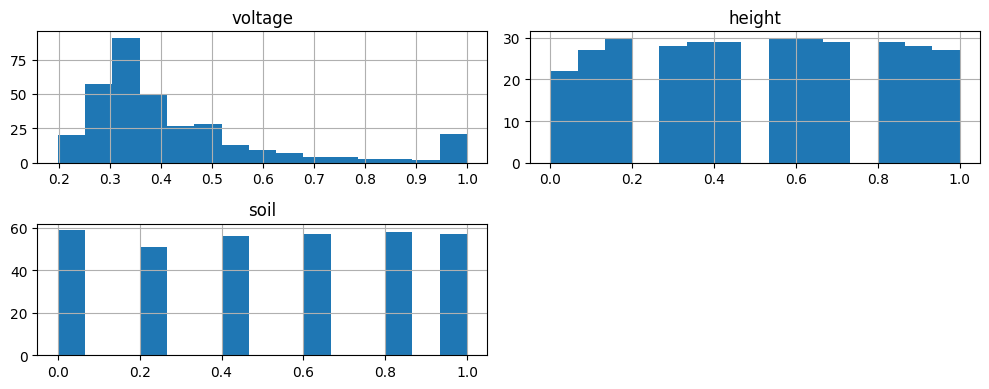

Size of training: 169
Size of test:  169
Training proportions: 
mine_type
1            0.207101
2            0.207101
3            0.195266
4            0.195266
5            0.195266
Name: proportion, dtype: float64
Test proportions:
mine_type
1            0.213018
2            0.207101
3            0.195266
4            0.195266
5            0.189349
Name: proportion, dtype: float64
Scaled feature range: 
     voltage  height  soil
min      0.0     0.0   0.0
max      1.0     1.0   1.0
k =  1 Accuracy =  0.462
k =  3 Accuracy =  0.385
k =  5 Accuracy =  0.355
k =  7 Accuracy =  0.337
k =  9 Accuracy =  0.373
k =  11 Accuracy =  0.379
k =  15 Accuracy =  0.385
Best k:  1
Accuracy of Test:  0.462
Accuracy % 46.15


/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/maleahcaboteja/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A col

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,21,0,4,4,7
Actual 2,0,32,0,3,0
Actual 3,8,0,7,10,8
Actual 4,7,5,4,11,6
Actual 5,7,0,9,9,7


In [35]:
# Your Phase 2 solution to the problem goes here.
# Your Phase 1 solution to the problem goes here.

from matplotlib import pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
#Q2
#I answered the questions in the comments under the question number :)


#1. 

#loads csv data and performs multiple EDA
df = pd.read_csv('data/land_mines.csv')
print(df.head())
print(df.describe())
print(df.shape)

print(df.info())
print(df.isnull().sum())

#summarizes the target label and features
print(df["mine_type"].value_counts().sort_index())
print(df["mine_type"].value_counts(normalize=True).sort_index())

feature_stats = ["voltage","height","soil"]
print(df[feature_stats].describe())

#looks at a histogram layout of the features
df[feature_stats].hist(figsize=(10,4), bins=15)
plt.tight_layout()
plt.show()

#2.
#looks at all mine types to evaluate
feature_x = df[["voltage", "height", "soil"]]
feature_y = df[["mine_type"]]
train_x, test_x, train_y, test_y = train_test_split(feature_x,feature_y,test_size=0.50,random_state=42,stratify=feature_y)


print("Size of training:", len(train_x))
print("Size of test: ", len(test_x))
print("Training proportions: ")
print(train_y.value_counts(normalize=True).sort_index())
print("Test proportions:")
print(test_y.value_counts(normalize=True).sort_index())

#3. 
#I tested multiple values of k (1,3,5,7,9,11,15) and compared the accuracy of them, and then selected the k with 
# the highest accuracy. I selected k = 1 because it had the highest accuracy of about 46.2% in comparison 
# to the other values. The final model I made had a test accuracy of 46.15%. 

#scales the mining features based off what we did in class
scaler = MinMaxScaler()
train_x_scaled = pd.DataFrame(scaler.fit_transform(train_x),columns=train_x.columns,index=train_x.index)
test_x_scaled = pd.DataFrame(scaler.transform(test_x),columns=test_x.columns,index=test_x.index)

print("Scaled feature range: ")
print(train_x_scaled.agg(["min", "max"]).round(3))

#builds k-NN classifiers, choosing k values
values = [1,3,5,7,9,11,15]

for k in values:
    model_k = KNeighborsClassifier(n_neighbors=k)
    fitted_k_model = model_k.fit(train_x_scaled, train_y)
    hat_y = fitted_k_model.predict(test_x_scaled)
    accuracy = accuracy_score(test_y,hat_y)

    print("k = ",k,"Accuracy = ", round(accuracy,3))

#final model and the accuracy

highest_k = 1
model_k = KNeighborsClassifier(n_neighbors=highest_k)
fitted_k_model = model_k.fit(train_x_scaled, train_y)
hat_y = fitted_k_model.predict(test_x_scaled)

accuracy = accuracy_score(test_y,hat_y)

print("Best k: ", highest_k)
print("Accuracy of Test: ", round(accuracy, 3))
print("Accuracy %", round(accuracy * 100, 2))

#4.
#The confusion matrix reflects that the model is best when predicting the type 2 mine type because it 
# classifies 32/35 correctly for that mine type. It's less accurate when predeicting for mines 3 and 5,
# where it classifies 7/33 type 3 mines and 7/32 for type 5 mines. It seems to struggle with 
# determining the difference between mine 3, 4, adn 5 types because they are incorrectly predicted as 
# the other mine types. So there was only 78/169 tests that the model correctly classified, which is 
# how we get the 46.15% accuracy. 

#confusion matrix to analyze
cm = confusion_matrix(test_y, hat_y, labels=[1, 2, 3, 4, 5])
confusion_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)

confusion_table


#5. 
#Advice I have for those who are using this predictive model would be that they should 
# refer to the manual ways of analyzing such as referencing the confusion matrix in order
# to understand the level of accuracy with the predictions against the actual values. 
# By understanding the actual values and seeing where the predictions are most inaccurate, we
# would be able to make mistakes when evaluating the data/outputs that are inconsistent in this
# model. 
    

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I decided to keep my code because its accuracy to what needed to be done for the assignment was correct and it only suggested things that related to syntax, cohesion, and suggestive options when making the logic more concise. I think AI did a good job at determing the correctness, but sometimes it just gives unnecessary changes that doesn't really make a difference when evaluating the code's logic. I also only used chatgpt which is pretty straightforward with minimal suggestions, but in prior times when I use claude sometimes I feel that claude goes more in depth and provides more suggestiosn than chatgpt does. The solution always goes line by line question by question for all LLMs, which makes it easy to follow especially when you're trying to edit you code line by line, section by section. I also think that the only limitation is that sometimes that LLMs suggest imports that you might not know how to use which is also a part of why I rejected some of the suggestions because I wanted to just use the ones talked about in class.